# Introduzione all'analisi dei dati

## Metodi numerici per l'analisi dei dati

Viviamo in un mondo in cui una grande quantità di informazioni viene raccolta continuamente: immagini mediche, misure ambientali, transazioni economiche, dati provenienti dai social network, segnali acquisiti da sensori e risultati di esperimenti scientifici.

Queste informazioni vengono rappresentate sotto forma di **dati**. Tuttavia, possedere molti dati non significa automaticamente possedere conoscenza. I dati possono essere incompleti, rumorosi, ridondanti o difficili da interpretare.

L'obiettivo dell'**analisi dei dati** è estrarre dai dati informazioni significative, individuare regolarità e costruire modelli utili per descrivere o prevedere un fenomeno.

Possiamo riassumere il processo nel seguente schema:

$$
\text{dati grezzi}
\longrightarrow
\text{rappresentazione matematica}
\longrightarrow
\text{metodo numerico}
\longrightarrow
\text{informazione}.
$$

## Obiettivi della lezione

Al termine di questa introduzione dovremmo essere in grado di:

- spiegare che cosa si intende per analisi dei dati;
- distinguere osservazioni, variabili e caratteristiche;
- rappresentare un insieme di dati mediante vettori e matrici;
- riconoscere diversi tipi di analisi;
- effettuare una prima esplorazione numerica e grafica dei dati;
- comprendere il ruolo del rumore, dell'errore e dei metodi numerici.

## L'analisi dei dati è interdisciplinare

L'analisi dei dati si trova all'intersezione di tre aree:

- **informatica**, necessaria per rappresentare, elaborare e gestire i dati;
- **matematica e statistica**, che forniscono modelli e strumenti per interpretarli;
- **conoscenza del dominio applicativo**, indispensabile per formulare domande sensate e valutare i risultati.

```{figure} immagini_sorgente/an_dati1.png
---
width: 60%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\an_dati1.png"  width="400">
</p>

Un risultato numericamente corretto non è necessariamente utile: deve anche essere coerente con il problema reale.

## Il ciclo di vita dell'analisi dei dati

Un progetto di analisi dei dati non coincide con la sola costruzione di un modello. È un processo iterativo: si formula il problema, si raccolgono e preparano i dati, si esplorano le informazioni disponibili, si costruisce il modello e se ne valuta l'efficacia.

```{figure} immagini_sorgente/an_dati2.png
---
width: 60%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\an_dati2.png"  width="400">
</p>


I risultati ottenuti possono suggerire di modificare il modello, raccogliere nuovi dati o persino riformulare la domanda iniziale.

## Il focus del corso: l'analisi predittiva

In questo corso ci concentreremo soprattutto sull'**analisi predittiva**. A partire da esempi per i quali conosciamo già la risposta, cercheremo di costruire una funzione capace di fornire una previsione su nuove osservazioni.

In forma schematica:

$$
\text{dati di esempio}
\longrightarrow
\text{apprendimento di un modello}
\longrightarrow
\text{previsione su nuovi dati}.
$$

Due problemi predittivi fondamentali sono:

- la **classificazione**, quando la risposta è una categoria;
- la **regressione**, quando la risposta è una quantità numerica.

Cominciamo dall'idea di classificazione.

## Un primo esempio

Supponiamo di conoscere, per un insieme di studenti:

- il numero di ore dedicate allo studio;
- la percentuale di lezioni frequentate;
- il voto ottenuto all'esame.

A partire da questi dati possiamo formulare diverse domande:

- Qual è il voto medio?
- Quanto sono variabili i risultati?
- Esiste una relazione tra ore di studio e voto?
- Sono presenti studenti con un comportamento anomalo?
- Possiamo dividere gli studenti in gruppi con caratteristiche simili?

Prima di scegliere un algoritmo dobbiamo quindi chiarire **quale domanda vogliamo porre ai dati**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

studenti = pd.DataFrame({
    'Studente': ['Anna', 'Bruno', 'Carla', 'Davide', 'Elena', 'Fabio', 'Giulia', 'Luca'],
    'Ore_studio': [12, 25, 18, 8, 22, 15, 28, 10],
    'Frequenza': [70, 90, 80, 60, 85, 75, 95, 65],
    'Voto': [21, 28, 25, 19, 27, 23, 30, 20]
})

studenti

,Studente,Ore_studio,Frequenza,Voto
0,Anna,12,70,21
1,Bruno,25,90,28
2,Carla,18,80,25
3,Davide,8,60,19
4,Elena,22,85,27
5,Fabio,15,75,23
6,Giulia,28,95,30
7,Luca,10,65,20


Nella tabella precedente:

- ogni **riga** corrisponde a un'osservazione, cioè a uno studente;
- ogni **colonna** corrisponde a una variabile;
- le variabili numeriche possono essere utilizzate nei calcoli;
- il nome dello studente è invece una variabile identificativa.

## Che cos'è l'analisi dei dati?

L'analisi dei dati comprende l'insieme delle tecniche utilizzate per:

1. raccogliere e organizzare i dati;
2. controllarne qualità e coerenza;
3. rappresentarli in una forma matematica;
4. esplorarli mediante statistiche e visualizzazioni;
5. individuare relazioni e strutture;
6. costruire e valutare modelli;
7. formulare previsioni o prendere decisioni.

L'analisi dei dati non è quindi una singola tecnica, ma un **processo** nel quale matematica, statistica e informatica interagiscono.

## Diversi tipi di analisi

### Analisi descrittiva

Risponde alla domanda: **che cosa mostrano i dati?**

Comprende, per esempio, il calcolo di media, mediana, varianza e quantili, oltre alla costruzione di tabelle e grafici.

### Analisi esplorativa

Cerca strutture non note in anticipo, come gruppi di osservazioni simili, variabili associate, dati anomali e direzioni principali di variabilità.

### Analisi predittiva

Utilizza i dati disponibili per prevedere quantità non ancora osservate. Alcuni esempi sono prevedere il prezzo di un'abitazione, classificare un messaggio come spam o riconoscere un oggetto in un'immagine.

### Analisi prescrittiva

Cerca di determinare quale azione sia più conveniente sulla base dei dati. In questo caso l'analisi dei dati si collega direttamente ai problemi di ottimizzazione.

## Come vengono rappresentati i dati?

Se per ogni oggetto misuriamo $n$ caratteristiche, una singola osservazione può essere rappresentata mediante un vettore

$$
\mathbf{x}=
\begin{bmatrix}
x_1 \\ x_2 \\ \vdots \\ x_n
\end{bmatrix}
\in\mathbb{R}^n.
$$

Se disponiamo di $m$ osservazioni, possiamo raccoglierle in una matrice

$$
A=
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\n
a_{21} & a_{22} & \cdots & a_{2n} \\n
\vdots & \vdots & \ddots & \vdots \\n
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix}
\in\mathbb{R}^{m\times n}.
$$

Ogni riga rappresenta un'osservazione; ogni colonna rappresenta una caratteristica, detta anche **variabile** o **feature**. Molti problemi di analisi dei dati possono così essere ricondotti a operazioni di algebra lineare.

In [2]:
# Estraiamo dalla tabella la matrice dei dati numerici
A = studenti[['Ore_studio', 'Frequenza', 'Voto']].to_numpy()

print('Matrice dei dati:')
print(A)
print(f'\nNumero di osservazioni: {A.shape[0]}')
print(f'Numero di variabili: {A.shape[1]}')

Matrice dei dati:
[[12 70 21]
 [25 90 28]
 [18 80 25]
 [ 8 60 19]
 [22 85 27]
 [15 75 23]
 [28 95 30]
 [10 65 20]]

Numero di osservazioni: 8
Numero di variabili: 3


## Prime statistiche descrittive

La **media** di una variabile $x$ composta da $m$ osservazioni è

$$
\overline{x}=\frac{1}{m}\sum_{i=1}^{m}x_i.
$$

La media riassume il livello centrale dei dati, ma non descrive quanto essi siano dispersi. Una misura della dispersione è la **deviazione standard**:

$$
s=\sqrt{\frac{1}{m-1}\sum_{i=1}^{m}(x_i-\overline{x})^2}.
$$

La mediana e i quantili sono spesso più robusti della media in presenza di valori anomali.

In [3]:
studenti[['Ore_studio', 'Frequenza', 'Voto']].describe().round(2)

,Ore_studio,Frequenza,Voto
count,8.00,8.00,8.00
mean,17.25,77.50,24.12
std,7.27,12.25,4.02
min,8.00,60.00,19.00
25%,11.50,68.75,20.75
50%,16.50,77.50,24.00
75%,22.75,86.25,27.25
max,28.00,95.00,30.00


### Esercizio

Calcolare direttamente con NumPy la media, la mediana e la deviazione standard dei voti. Confrontare i risultati con la tabella precedente.

> **Attenzione:** NumPy utilizza per impostazione predefinita la deviazione standard della popolazione. Per ottenere quella campionaria, coerente con `pandas.DataFrame.describe()`, occorre specificare `ddof=1`.

In [4]:
voti = studenti['Voto'].to_numpy()

print('Media:', np.mean(voti))
print('Mediana:', np.median(voti))
print('Deviazione standard campionaria:', np.std(voti, ddof=1))

Media: 24.125
Mediana: 24.0
Deviazione standard campionaria: 4.0155946010522525


## Visualizzare i dati

Le sole statistiche riassuntive possono nascondere caratteristiche importanti. I grafici aiutano a riconoscere distribuzioni, relazioni e possibili valori anomali.

Un **istogramma** mostra come sono distribuiti i valori di una variabile. Un **diagramma di dispersione** (*scatter plot*) rappresenta invece due variabili e permette di osservare eventuali associazioni.

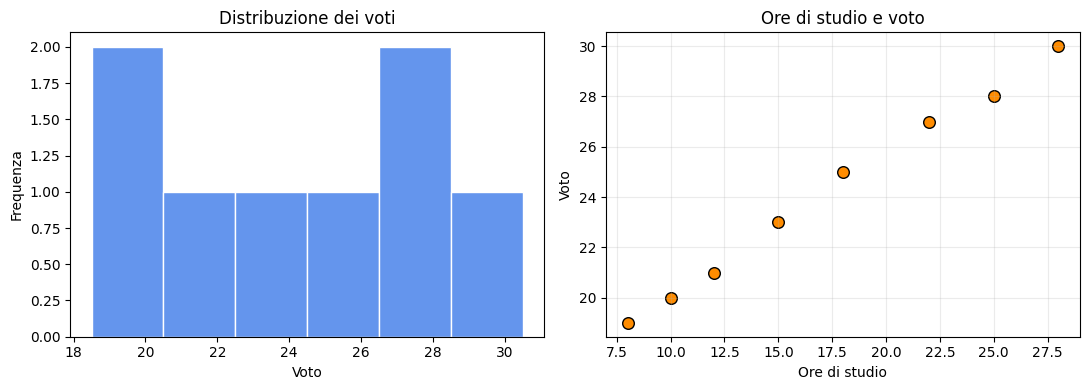

In [5]:
fig, assi = plt.subplots(1, 2, figsize=(11, 4))

assi[0].hist(studenti['Voto'], bins=np.arange(18.5, 31.5, 2),
             color='cornflowerblue', edgecolor='white')
assi[0].set_title('Distribuzione dei voti')
assi[0].set_xlabel('Voto')
assi[0].set_ylabel('Frequenza')

assi[1].scatter(studenti['Ore_studio'], studenti['Voto'],
                s=70, color='darkorange', edgecolor='black')
assi[1].set_title('Ore di studio e voto')
assi[1].set_xlabel('Ore di studio')
assi[1].set_ylabel('Voto')
assi[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Dati, informazione e conoscenza

È utile distinguere tre concetti:

- i **dati** sono le osservazioni raccolte;
- l'**informazione** nasce dall'organizzazione e dall'interpretazione dei dati;
- la **conoscenza** permette di utilizzare l'informazione per comprendere un fenomeno o prendere decisioni.

Un algoritmo può individuare una struttura nei dati, ma il risultato deve essere interpretato nel contesto del problema. Un'associazione tra due variabili, per esempio, non implica necessariamente una relazione di causa ed effetto.

## La qualità dei dati

Prima di applicare qualsiasi metodo è necessario esaminare la qualità dei dati. I problemi più comuni sono:

- **valori mancanti**, dovuti a misure non effettuate o informazioni non disponibili;
- **valori anomali** (*outlier*), molto lontani dalla maggior parte delle osservazioni;
- **errori di acquisizione o trascrizione**;
- **unità di misura differenti**;
- **duplicati**;
- **campioni non rappresentativi** della popolazione che vogliamo studiare.

La pulizia dei dati non è un passaggio secondario: risultati numericamente corretti possono essere privi di significato se i dati di partenza sono inaffidabili.

In [6]:
# Un piccolo esempio contenente un valore mancante e un valore sospetto
dati_problematici = studenti.copy()
dati_problematici.loc[2, 'Frequenza'] = np.nan
dati_problematici.loc[6, 'Ore_studio'] = 280

display(dati_problematici)
print('\nValori mancanti per colonna:')
display(dati_problematici.isna().sum())

,Studente,Ore_studio,Frequenza,Voto
0,Anna,12,70.0,21
1,Bruno,25,90.0,28
2,Carla,18,NaN,25
3,Davide,8,60.0,19
4,Elena,22,85.0,27
5,Fabio,15,75.0,23
6,Giulia,280,95.0,30
7,Luca,10,65.0,20



Valori mancanti per colonna:


Studente      0
Ore_studio    0
Frequenza     1
Voto          0
dtype: int64

### Domande

1. Il valore `280` è necessariamente errato?
2. Come potremmo verificare se si tratta di un errore?
3. È sempre corretto eliminare una riga contenente un valore mancante?
4. Che cosa accade alla media delle ore di studio in presenza del valore sospetto?

Non esiste una risposta automatica valida in ogni situazione: le scelte dipendono dal significato dei dati e dallo scopo dell'analisi.

## Il ruolo dell'errore e del rumore

L'errore è inevitabile nell'analisi dei dati. Può derivare da errori di misura, dati mancanti, rumore, approssimazioni del modello, errori di arrotondamento o interruzione anticipata di un algoritmo iterativo.

Possiamo rappresentare una misura mediante

$$
y^\delta = y + \eta,
$$

dove $y$ è il valore ideale, $\eta$ rappresenta il rumore e $y^\delta$ è il dato effettivamente osservato.

Un algoritmo affidabile deve estrarre l'informazione utile senza interpretare il rumore come una caratteristica significativa del fenomeno.

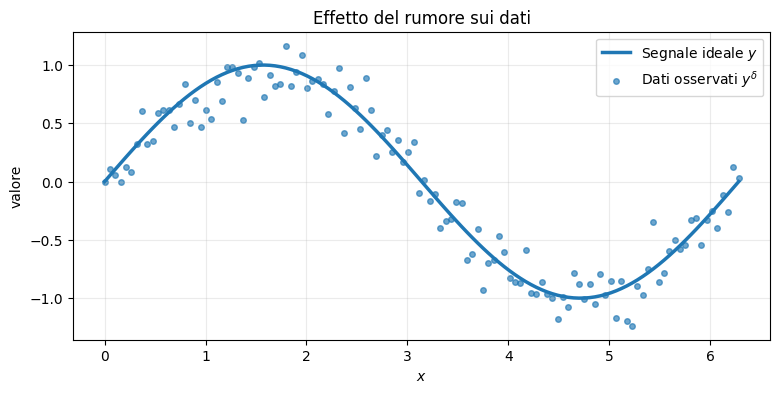

In [7]:
# Segnale ideale e misure rumorose
rng = np.random.default_rng(7)
x = np.linspace(0, 2 * np.pi, 120)
y = np.sin(x)
eta = 0.18 * rng.standard_normal(x.size)
y_delta = y + eta

plt.figure(figsize=(9, 4))
plt.plot(x, y, linewidth=2.5, label='Segnale ideale $y$')
plt.scatter(x, y_delta, s=16, alpha=0.65, label=r'Dati osservati $y^\delta$')
plt.xlabel('$x$')
plt.ylabel('valore')
plt.title('Effetto del rumore sui dati')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Perché servono i metodi numerici?

Nei problemi reali raramente è possibile ottenere una soluzione esatta mediante una formula. I dati possono essere numerosi, rumorosi o mal condizionati, e il modello può essere troppo complesso per essere trattato analiticamente.

I metodi numerici consentono di calcolare una soluzione approssimata utilizzando un calcolatore. È però necessario porsi alcune domande fondamentali:

- L'algoritmo produce una soluzione sufficientemente accurata?
- Quanto è grande l'errore?
- La soluzione cambia molto se i dati sono perturbati?
- Quanto tempo e quanta memoria sono necessari?
- L'algoritmo converge?
- Il risultato descrive davvero il fenomeno oppure riproduce anche il rumore?

Un metodo numerico non deve quindi essere soltanto implementabile: deve anche essere **accurato, stabile ed efficiente**.

## La pipeline dell'analisi dei dati

Nel corso utilizzeremo ripetutamente la seguente sequenza concettuale:

$$
\boxed{
\text{problema}
\rightarrow
\text{dati}
\rightarrow
\text{modello}
\rightarrow
\text{algoritmo}
\rightarrow
\text{valutazione}
}
$$

Il messaggio centrale è:

> L'analisi dei dati non consiste semplicemente nell'applicare un algoritmo. Consiste nel formulare correttamente una domanda, rappresentare i dati, scegliere un modello, calcolare una soluzione e valutarne criticamente l'affidabilità.

## Per riflettere

Consideriamo un'applicazione che deve analizzare automaticamente immagini mediche.

1. Che cosa rappresentano le osservazioni?
2. Quali potrebbero essere le variabili o feature?
3. Da quali sorgenti potrebbe provenire il rumore?
4. Quali conseguenze potrebbe avere un errore dell'algoritmo?
5. L'accuratezza numerica è l'unico criterio con cui valutarlo?

Queste domande mostrano perché l'analisi dei dati richiede sia strumenti matematici e computazionali sia una conoscenza del contesto applicativo.

# Dall'analisi descrittiva all'analisi predittiva

Descrivere i dati disponibili è soltanto una parte dell'analisi dei dati. Molto spesso vogliamo utilizzare ciò che abbiamo osservato per formulare una **previsione su nuovi dati**.

Esempi di domande predittive sono:

- un messaggio di posta elettronica è *spam* oppure *non spam*?
- un'immagine contiene un gatto, un cane oppure un altro animale?
- una transazione bancaria è regolare oppure fraudolenta?
- un'immagine medica mostra un tessuto sano oppure patologico?

Quando il risultato da prevedere appartiene a un insieme finito di categorie, abbiamo un problema di **classificazione**.

## Che cos'è un classificatore?

Ogni oggetto viene descritto mediante un insieme di caratteristiche numeriche, dette **feature**. Queste caratteristiche formano un vettore

$$
\mathbf{x}=(x_1,x_2,\ldots,x_n)\in\mathbb{R}^n.
$$

Un classificatore riceve il vettore $\mathbf{x}$ e gli assegna una classe:

$$
f:\mathbb{R}^n\longrightarrow\{C_1,C_2,\ldots,C_K\}.
$$

```{figure} immagini_sorgente/schema_classificazione.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/schema_classificazione.png" width="700">
</p>

## Apprendimento supervisionato

Come possiamo costruire la funzione $f$? Disponiamo di un insieme di esempi per i quali la classe corretta è già nota:

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^m,
$$

dove $\mathbf{x}_i$ contiene le caratteristiche dell'osservazione $i$ e $y_i$ è la sua **etichetta**, o *label*.

Si parla di **apprendimento supervisionato** perché durante l'apprendimento il metodo conosce sia i dati in ingresso sia le risposte corrette.

## Un piccolo dataset a due classi

Consideriamo dodici oggetti. Ogni oggetto è descritto da due caratteristiche, $x_1$ e $x_2$, ed è associato alla **classe A** oppure alla **classe B**. Poiché ci sono soltanto due possibili etichette, questo è un problema di **classificazione binaria**.

```{figure} immagini_sorgente/dati_due_classi.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/dati_due_classi.png" width="700">
</p>

Ogni punto rappresenta un'osservazione. La sua posizione dipende dalle caratteristiche, mentre il colore e la forma indicano la classe nota.

Se le possibili etichette fossero più di due, per esempio gatto, cane e cavallo, parleremmo invece di **classificazione multiclasse**.

## La frontiera di decisione

Il classificatore suddivide lo spazio delle caratteristiche in regioni associate alle diverse classi. Il confine tra queste regioni prende il nome di **frontiera di decisione**.

```{figure} immagini_sorgente/frontiera_classificazione.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/frontiera_classificazione.png" width="700">
</p>

Una volta costruita la frontiera, una nuova osservazione viene classificata in base alla regione in cui si trova.

> La frontiera mostrata nella figura serve soltanto a illustrare il concetto: nei problemi reali deve essere appresa dai dati.

## Dal training alla previsione

Il processo può essere suddiviso in due fasi:

1. **Training:** dagli esempi etichettati si determina una regola di classificazione.
2. **Predizione:** la regola appresa viene applicata a osservazioni mai viste prima.

È importante non valutare il metodo soltanto sui dati utilizzati per costruirlo. Per questo il dataset viene normalmente suddiviso in:

- **training set**, utilizzato per apprendere il classificatore;
- **test set**, utilizzato per valutarlo su esempi non impiegati durante l'apprendimento.

Una prima misura delle prestazioni è l'**accuratezza**:

$$
\operatorname{accuracy}=
\frac{\text{numero di classificazioni corrette}}{\text{numero totale di esempi}}.
$$

## Domande per la discussione

1. Quali sono l'input e l'output di un classificatore di immagini?
2. Che differenza c'è tra classificazione binaria e multiclasse?
3. Come classificheremmo un punto molto vicino alla frontiera di decisione?
4. Che cosa accade se le osservazioni delle due classi si sovrappongono?
5. Perché non è sufficiente misurare l'accuratezza sul training set?
6. In ambito medico, un falso positivo e un falso negativo hanno sempre lo stesso costo?

# Una prima idea di classificazione

Consideriamo un insieme di fiori descritti mediante due caratteristiche:

- la lunghezza del petalo;
- la larghezza del petalo.

Per ogni fiore conosciamo inoltre la specie, che può essere **Setosa** oppure **Versicolor**. La specie è la **classe** o **etichetta** (*label*) che vogliamo prevedere.

Il nostro obiettivo è usare gli esempi disponibili per assegnare una classe a un nuovo fiore.

In [8]:
# Un piccolo dataset ispirato al dataset Iris
fiori = pd.DataFrame({
    'Lunghezza_petalo': [1.4, 1.3, 1.5, 1.7, 1.4, 1.6,
                         4.7, 4.5, 4.9, 4.0, 4.6, 4.4],
    'Larghezza_petalo': [0.2, 0.2, 0.2, 0.4, 0.3, 0.2,
                         1.4, 1.5, 1.5, 1.3, 1.5, 1.3],
    'Specie': ['Setosa'] * 6 + ['Versicolor'] * 6
})

fiori

,Lunghezza_petalo,Larghezza_petalo,Specie
0,1.4,0.2,Setosa
1,1.3,0.2,Setosa
2,1.5,0.2,Setosa
3,1.7,0.4,Setosa
4,1.4,0.3,Setosa
5,1.6,0.2,Setosa
6,4.7,1.4,Versicolor
7,4.5,1.5,Versicolor
8,4.9,1.5,Versicolor
9,4.0,1.3,Versicolor


In un problema di apprendimento supervisionato ogni osservazione è formata da:

$$
(\mathbf{x}_i,y_i), \qquad i=1,\ldots,m,
$$

dove

$$
\mathbf{x}_i=
\begin{bmatrix}
\text{lunghezza del petalo}\\
\text{larghezza del petalo}
\end{bmatrix}
\in\mathbb{R}^2
$$

è il vettore delle caratteristiche e $y_i$ è l'etichetta associata al fiore.

In questo esempio cerchiamo quindi una funzione

$$
f:\mathbb{R}^2\longrightarrow\{\text{Setosa},\text{Versicolor}\}.
$$

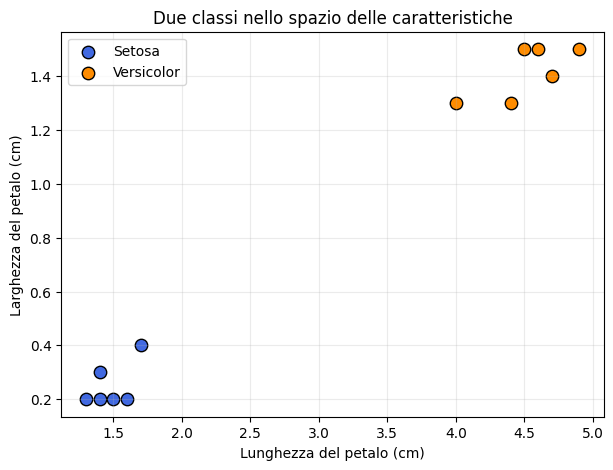

In [9]:
colori = {'Setosa': 'royalblue', 'Versicolor': 'darkorange'}

plt.figure(figsize=(7, 5))
for specie, gruppo in fiori.groupby('Specie'):
    plt.scatter(gruppo['Lunghezza_petalo'], gruppo['Larghezza_petalo'],
                s=80, color=colori[specie], edgecolor='black', label=specie)

plt.xlabel('Lunghezza del petalo (cm)')
plt.ylabel('Larghezza del petalo (cm)')
plt.title('Due classi nello spazio delle caratteristiche')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Nel grafico ogni punto rappresenta un fiore. La posizione dipende dalle sue caratteristiche, mentre il colore indica la classe nota.

Osserviamo che le due specie occupano regioni differenti dello spazio. Un metodo di classificazione cerca di ricavare dai dati una **regola di decisione** che separi tali regioni.

Per un nuovo fiore con caratteristiche

$$
\mathbf{x}_{\mathrm{new}}=
\begin{bmatrix}
4.2\\1.4
\end{bmatrix},
$$

quale classe assegneremmo osservando il grafico?

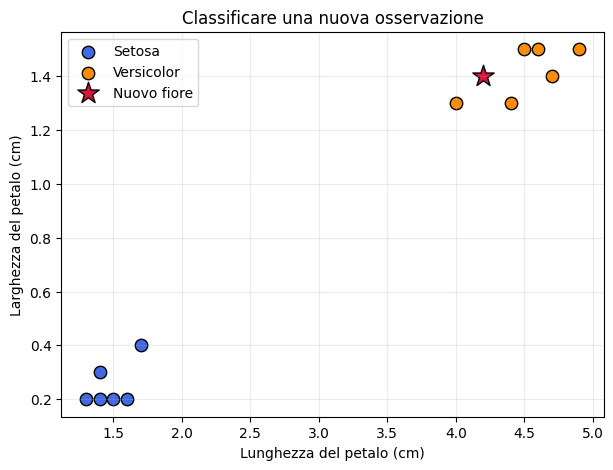

In [10]:
nuovo_fiore = np.array([4.2, 1.4])

plt.figure(figsize=(7, 5))
for specie, gruppo in fiori.groupby('Specie'):
    plt.scatter(gruppo['Lunghezza_petalo'], gruppo['Larghezza_petalo'],
                s=80, color=colori[specie], edgecolor='black', label=specie)

plt.scatter(nuovo_fiore[0], nuovo_fiore[1], marker='*', s=260,
            color='crimson', edgecolor='black', label='Nuovo fiore')
plt.xlabel('Lunghezza del petalo (cm)')
plt.ylabel('Larghezza del petalo (cm)')
plt.title('Classificare una nuova osservazione')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Apprendimento e valutazione

I dati usati per costruire la regola di classificazione costituiscono il **training set**. Valutare il modello sugli stessi esempi, però, non ci dice quanto sarà efficace su dati mai osservati.

Per questo si separano normalmente i dati in:

- **training set**, utilizzato per apprendere il modello;
- **test set**, utilizzato per valutarne la capacità predittiva su nuovi dati.

Una prima misura di prestazione è l'**accuratezza**:

$$
\operatorname{accuracy}=
\frac{\text{numero di classificazioni corrette}}
{\text{numero totale di esempi nel test set}}.
$$

Nei problemi reali l'accuratezza non è sempre sufficiente: il significato e il costo dei diversi tipi di errore possono essere molto differenti.

### Domande per la discussione

1. Quali informazioni costituiscono l'input del classificatore?
2. Qual è l'output?
3. Il problema è binario o multiclasse?
4. Che cosa accadrebbe se le due nuvole di punti si sovrapponessero?
5. È possibile ottenere un'accuratezza perfetta sul training set ma commettere errori sui nuovi dati?
6. In una diagnosi medica, tutti gli errori di classificazione avrebbero lo stesso costo?

# Approssimazione dei dati: modelli predittivi

Supponiamo di avere un insieme di dati

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n},
$$

dove $x_i$ è il dato in ingresso e $y_i$ è il valore osservato.

L'obiettivo è determinare una funzione che rappresenti nel modo migliore possibile la relazione tra $x$ e $y$ e che possa essere utilizzata per prevedere il valore corrispondente a un nuovo dato in ingresso.

## La scelta del modello

Gli stessi dati possono essere rappresentati utilizzando classi di funzioni differenti. Per esempio, possiamo scegliere come modello una retta oppure una parabola.

```{figure} immagini_sorgente/modelli_lineare_quadratico.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/modelli_lineare_quadratico.png" width="700">
</p>

Nel primo caso il modello ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x,
$$

mentre nel secondo caso ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

La famiglia scelta non deve necessariamente essere quella dei polinomi. Per esempio, possiamo considerare una combinazione lineare di una funzione esponenziale e di una costante:

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1 e^{\alpha x}.
$$

```{figure} immagini_sorgente/modello_esponenziale.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/modello_esponenziale.png" width="700">
</p>

La scelta della famiglia di funzioni dipende dal fenomeno che vogliamo descrivere e dalle informazioni disponibili sui dati.

## Famiglie parametriche di funzioni

Scelta una famiglia di funzioni $f(x;\boldsymbol{\theta})$, occorre determinare i parametri

$$
\boldsymbol{\theta}=(\theta_0,\theta_1,\ldots,\theta_{k-1})^T\in\mathbb{R}^{k}
$$

che identificano la particolare funzione della famiglia che meglio rappresenta i dati.

Per esempio, scegliendo come famiglia le rette del piano, dobbiamo determinare

$$
\boldsymbol{\theta}=(\theta_0,\theta_1)^T,
$$

dove $\theta_0$ è l'intercetta e $\theta_1$ è il coefficiente angolare. Il problema consiste quindi nel trovare la retta che meglio approssima i punti dati.

## Come confrontare due modelli?

Per stabilire se una funzione rappresenta i dati meglio di un'altra dobbiamo introdurre una misura di vicinanza tra i valori previsti e quelli osservati.

Questo viene fatto definendo una **funzione di costo**, detta anche **funzione di perdita** o *loss function*. Indicata con $h$ la perdita relativa a una singola osservazione, definiamo

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}h\bigl(f(x_i;\boldsymbol{\theta}),y_i\bigr).
$$

La funzione di costo dipende dai parametri perché, al variare di $\boldsymbol{\theta}$, cambiano le previsioni del modello.

## Il calcolo dei parametri come problema di minimo

I parametri ottimali sono quelli che rendono minima la funzione di costo:

$$
\boldsymbol{\theta}^{*}
=\operatorname*{argmin}_{\boldsymbol{\theta}\in\mathbb{R}^{k}}
\mathcal{L}(\boldsymbol{\theta}).
$$

La funzione $f(x;\boldsymbol{\theta}^{*})$, i cui parametri sono stati stimati minimizzando la funzione di perdita, prende il nome di **funzione di regressione**.

> Il problema di costruire un modello predittivo viene così trasformato in un problema di ottimizzazione.

# L'approccio del Machine Learning

Nella programmazione tradizionale il programmatore specifica esplicitamente le regole che trasformano i dati in risultati. Questo approccio diventa difficile quando le regole sono troppo numerose, complesse o impossibili da descrivere in modo preciso.

Nel **Machine Learning** non scriviamo direttamente tutte le regole: forniamo esempi a un algoritmo, che cerca nei dati le regolarità utili per costruire un modello predittivo.

```{figure} immagini_sorgente/tradizionale_vs_ml.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/tradizionale_vs_ml.png" width="700">
</p>

> Un sistema di Machine Learning apprende dai dati una regola che non è stata programmata esplicitamente.

# Imparare dagli esempi

L'apprendimento automatico può essere paragonato allo studio di uno studente:

- durante il **training**, lo studente studia esempi ed esercizi già svolti;
- durante il **test**, affronta domande nuove;
- la **valutazione** misura quanto ciò che ha appreso sia trasferibile a situazioni mai viste.

```{figure} immagini_sorgente/studying_training_evaluation.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/studying_training_evaluation.png" width="700">
</p>

Se le domande dell'esame fossero identiche agli esercizi studiati, non potremmo capire se lo studente ha davvero imparato. Analogamente, un modello deve essere valutato su dati non utilizzati durante il training.

# Dati, algoritmo di apprendimento e modello

Nell'**apprendimento supervisionato** disponiamo di un insieme di esempi

$$
\mathcal{D}_{\mathrm{train}}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{m},
$$

dove $\mathbf{x}_i$ contiene le caratteristiche dell'osservazione e $y_i$ è la risposta corretta.

L'**algoritmo di apprendimento** usa il training set per determinare un modello $f_{\boldsymbol{\theta}}$. Una volta costruito, il modello riceve un nuovo input e produce una previsione:

$$
\mathbf{x}_{\mathrm{new}}
\longrightarrow
f_{\boldsymbol{\theta}}(\mathbf{x}_{\mathrm{new}})
=\widehat{y}_{\mathrm{new}}.
$$

È importante distinguere:

- l'**algoritmo**, cioè la procedura che apprende;
- il **modello**, cioè la funzione ottenuta al termine dell'apprendimento;
- la **predizione**, cioè l'output del modello per un nuovo dato.

# Due problemi predittivi fondamentali

Nell'apprendimento supervisionato distinguiamo soprattutto:

- **classificazione**, se $y$ è una categoria;
- **regressione**, se $y$ è una quantità numerica.

```{figure} immagini_sorgente/classificazione_regressione.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/classificazione_regressione.png" width="700">
</p>

In entrambi i casi il modello deve individuare una relazione tra gli input e gli output osservati, per poi applicarla a nuovi dati. Cambiano il tipo di risposta e le misure utilizzate per valutare l'errore.

# L'obiettivo: generalizzare

Lo scopo non è riprodurre perfettamente gli esempi già osservati, ma ottenere buone previsioni su dati nuovi. Questa capacità prende il nome di **generalizzazione**.

```{figure} immagini_sorgente/training_validation_test.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/training_validation_test.png" width="700">
</p>

- Il **training set** serve ad apprendere i parametri del modello.
- Il **validation set** serve a confrontare scelte e configurazioni.
- Il **test set** deve essere usato soltanto per la valutazione finale.

Un modello troppo semplice può non cogliere la struttura dei dati (**underfitting**); un modello che si adatta anche al rumore del training set può invece non funzionare su nuovi dati (**overfitting**).

> La qualità di un modello si misura sulla sua capacità di prevedere, non sulla sua capacità di ricordare.

## Regressione e perdita quadratica

Nella regressione si utilizza frequentemente la perdita quadratica

$$
h\bigl(f(x_i;\boldsymbol{\theta}),y_i\bigr)
=\bigl(f(x_i;\boldsymbol{\theta})-y_i\bigr)^2.
$$

La funzione di costo diventa quindi

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}\bigl(f(x_i;\boldsymbol{\theta})-y_i\bigr)^2.
$$

Ogni termine misura il quadrato del residuo relativo all'osservazione $i$. Gli errori di segno opposto non si cancellano e gli errori grandi vengono penalizzati maggiormente.

## Regressione polinomiale

Nel caso della **regressione lineare**, il polinomio è una retta:

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x.
$$

Nel caso della **regressione quadratica**, il polinomio è una parabola:

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

In generale, un polinomio di grado $k$ dipende da $k+1$ parametri:

$$
f(x;\boldsymbol{\theta})
=\theta_0+\theta_1x+\theta_2x^2+\cdots+\theta_kx^k.
$$

## La funzione di perdita per la regressione polinomiale

Sostituendo il modello polinomiale nella perdita quadratica otteniamo

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}
\left(\theta_0+\theta_1x_i+\theta_2x_i^2+\cdots+\theta_kx_i^k-y_i\right)^2.
$$

Introduciamo i vettori

$$
\boldsymbol{\theta}=(\theta_0,\theta_1,\ldots,\theta_k)^T,
\qquad
\mathbf{y}=(y_1,y_2,\ldots,y_n)^T,
$$

e la matrice

$$
\Phi=
\begin{pmatrix}
x_1^0 & x_1^1 & \cdots & x_1^k\\
x_2^0 & x_2^1 & \cdots & x_2^k\\
\vdots & \vdots & \ddots & \vdots\\
x_n^0 & x_n^1 & \cdots & x_n^k
\end{pmatrix}
\in\mathbb{R}^{n\times(k+1)}.
$$

La matrice $\Phi$ viene spesso chiamata **matrice del modello** o **design matrix**.

## Formulazione matriciale

Il vettore delle previsioni del modello sui punti osservati è

$$
\widehat{\mathbf{y}}=\Phi\boldsymbol{\theta}.
$$

Il vettore dei residui è quindi

$$
\mathbf{r}=\Phi\boldsymbol{\theta}-\mathbf{y},
$$

e la funzione di perdita può essere scritta in forma compatta come

$$
\mathcal{L}(\boldsymbol{\theta})
=\|\Phi\boldsymbol{\theta}-\mathbf{y}\|_2^2.
$$

## Il problema dei minimi quadrati lineari

La determinazione dei coefficienti del polinomio conduce al problema

$$
\min_{\boldsymbol{\theta}\in\mathbb{R}^{k+1}}
\|\Phi\boldsymbol{\theta}-\mathbf{y}\|_2^2,
$$

che prende il nome di **problema dei minimi quadrati lineari**.

Il termine *lineare* si riferisce alla dipendenza del modello dai parametri $\boldsymbol{\theta}$, non necessariamente alla dipendenza dalla variabile $x$. Per esempio, il modello quadratico

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2
$$

non è lineare rispetto a $x$, ma è lineare rispetto ai parametri $\theta_0$, $\theta_1$ e $\theta_2$.

## Verso l'algebra lineare numerica

Il problema dei minimi quadrati

$$
\min_{\boldsymbol{\theta}\in\mathbb{R}^{k+1}}
\|\Phi\boldsymbol{\theta}-\mathbf{y}\|_2^2
$$

può essere risolto mediante tecniche di algebra lineare.

Per studiare come calcolare in modo accurato, stabile ed efficiente i parametri del modello, introduciamo quindi l'**algebra lineare numerica**, cioè l'approccio algoritmico che utilizza strumenti di algebra lineare per risolvere problemi numerici.